# Mapping the Internal Structure of Music

This project borrows its method from Visualizing Les Miserables, a digital
humanities project out of Northwestern. The idea there is simple. If two
characters show up in the same scene, you draw a line between them. Do that for
every scene and the lines pile up into a picture of how the whole novel is put
together: who is central, who sits off to the side, and which characters group
into tight clusters.

I wanted to try that same idea on a piece of music instead of a novel. A score
is also a structured text with parts that appear together and come back again.
My version of Hugo's "scene" is a fixed window of time in which notes sound
together. Inside each window I connect the things that happen at once, and then
I add those connections up across the whole piece.

I build two separate networks, each with one kind of node and one rule for
drawing an edge:

1. A pitch-class network. The nodes are the twelve pitch classes, and two of
   them get connected when they sound inside the same beat.
2. An instrument network. The nodes are the instrument parts, and two parts get
   connected when they both play inside the same measure.

The part I actually care about is the interpretation. I have played in
orchestras for years, so I already have a feel in my hands and ears for how
these pieces are built. The network lets me hold that feel up against something
I can see and measure, and the good moments are where the two agree, disagree,
or catch me off guard.

## Defining the nodes and edges

A "moment" in music can mean a lot of things. It might be an instant, a beat, or
a whole verse. Rather than leave that vague, I picked exact rules.

Pitch-class network

* Nodes: the twelve pitch classes (C, C#, D, all the way up to B). I collapse
  octaves with `pitch.pitchClass`, so every C counts as the same node and
  enharmonic spellings fold together. I seed all twelve at the start even if some
  never sound, so two different pieces produce graphs I can line up and compare.
* Edges: I cut the piece into quarter-note beats using the offset map. A note
  counts in every beat that its span `[onset, onset + duration)` touches, so a
  held note keeps connecting on each beat it actually sounds through. Any two
  pitch classes that fall in the same beat get an edge, and the edge weight is
  how many times that pairing comes up.

Instrument network

* Nodes: the instrument or part names.
* Edges: two parts get connected when both of them have notes sounding in the
  same measure. The weight is how often that happens.

I also build a measure-level version of the pitch network so I can show how much
the window choice changes the result. That change is one of the things worth
reporting on its own.

## The data and how to access it

All of the music in this project comes from the built-in music21 corpus, and that
was a deliberate choice. music21 ships with hundreds of fully encoded scores,
including the complete set of Bach four-voice chorales. There is nothing to
download by hand and nothing for me to host separately. Once music21 is installed
from `requirements.txt`, the data is already on your machine.

I reach the data two ways in this notebook:

* One named score: `m21.corpus.parse("bach/bwv66.6")`.
* A batch of chorales: `corpus.chorales.Iterator(1, 20)`, which returns the first
  twenty chorales as parsed scores.

You can browse what else is available with `m21.corpus.search("bach")`. If I later
want to analyze music that is not in the corpus, the same code accepts any
MusicXML or MIDI file through `m21.converter.parse("data/your_file.mid")`. In that
case I would commit the file into the `data/` folder of this repository so the
data travels with the project and anyone can rerun the notebook.

In [1]:
import math
import os
import itertools
from collections import Counter

import music21 as m21
from music21 import corpus
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("outputs", exist_ok=True)

# The twelve pitch classes, octave collapsed. pitchClass 0..11 indexes this list.
PC_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

print("Setup complete. Libraries loaded.")

Setup complete. Libraries loaded.


## The pipeline

I wrote the steps as small functions so I can run the same analysis on one piece
or on a few hundred. There are really two ideas at the core. Windowing cuts a
piece into comparable slices of time. Co-occurrence counting tallies which things
show up in the same slice.

In [2]:
def window_spans(score, kind="beat"):
    """Return a list of (window_id, start_offset, end_offset) spans.

    - "beat":    one window per quarter-note beat, i.e. [i, i+1).
    - "measure": one window per measure, taken from the score's offset map.
    """
    total = float(score.flatten().highestTime)
    if kind == "beat":
        n_beats = max(1, math.ceil(total))
        return [(i, float(i), float(i + 1)) for i in range(n_beats)]
    if kind == "measure":
        starts = sorted(score.parts[0].measureOffsetMap().keys())
        spans = []
        for i, start in enumerate(starts):
            end = starts[i + 1] if i + 1 < len(starts) else total
            spans.append((i + 1, float(start), float(end)))
        return spans
    raise ValueError(f"unknown window kind: {kind}")


def _overlaps(note_start, note_end, win_start, win_end):
    """True if a note's time span overlaps a window's span."""
    return win_start < note_end and win_end > note_start

In [3]:
def pitch_classes_by_window(score, kind="beat"):
    """Map each window -> SET of pitch classes (0..11) sounding in it.

    A note is counted in every window its [onset, onset+duration) span overlaps,
    so sustained notes connect across beats, not just on their onset beat.
    """
    spans = window_spans(score, kind)
    contents = {win_id: set() for win_id, _, _ in spans}
    for part in score.parts:
        for note in part.flatten().notes:
            start = float(note.offset)
            end = start + float(note.duration.quarterLength)
            if end == start:                     # grace note: give it an instant
                end = start + 1e-9
            for win_id, win_start, win_end in spans:
                if _overlaps(start, end, win_start, win_end):
                    for pitch in note.pitches:   # iterate so chords work too
                        contents[win_id].add(pitch.pitchClass)
    return contents


def instruments_by_window(score, kind="measure"):
    """Map each window -> SET of instrument/part names sounding in it."""
    spans = window_spans(score, kind)
    contents = {win_id: set() for win_id, _, _ in spans}
    for idx, part in enumerate(score.parts):
        name = part.partName or f"Part {idx + 1}"
        for note in part.flatten().notes:
            start = float(note.offset)
            end = start + float(note.duration.quarterLength)
            if end == start:
                end = start + 1e-9
            for win_id, win_start, win_end in spans:
                if _overlaps(start, end, win_start, win_end):
                    contents[win_id].add(name)
    return contents

In [4]:
def cooccurrence(window_contents):
    """Count how often each unordered pair co-occurs across all windows."""
    counts = Counter()
    for items in window_contents.values():
        for a, b in itertools.combinations(sorted(items), 2):
            counts[(a, b)] += 1
    return counts


def pitch_graph(counts):
    """Weighted graph whose nodes are ALL twelve pitch classes."""
    G = nx.Graph()
    G.add_nodes_from(range(12))              # seed all 12 -> comparable graphs
    for (a, b), weight in counts.items():
        G.add_edge(a, b, weight=weight)
    return G


def simple_graph(counts):
    """Weighted graph for arbitrary hashable nodes (e.g. instrument names)."""
    G = nx.Graph()
    for (a, b), weight in counts.items():
        G.add_edge(a, b, weight=weight)
    return G

## Load a score and find its key

I start with one of Bach's four-voice chorales, BWV 66.6, which ships with the
music21 corpus. I find the key first so I can come back to my first research
question later: do the most central pitch classes turn out to be the tonic and
dominant?

In [5]:
score = m21.corpus.parse("bach/bwv66.6")

key = score.analyze("key")
tonic_pc = key.tonic.pitchClass
dominant_pc = (tonic_pc + 7) % 12

print(f"Parts: {[p.partName for p in score.parts]}")
print(f"Detected key: {key}")
print(f"Tonic = {PC_NAMES[tonic_pc]}, Dominant = {PC_NAMES[dominant_pc]}")

Parts: ['Soprano', 'Alto', 'Tenor', 'Bass']
Detected key: f# minor
Tonic = F#, Dominant = C#


## Building the pitch-class network (beat window)

I slice the chorale into quarter-note beats, count which pitch classes share a
beat, and turn those counts into the twelve-node weighted graph.

In [6]:
beat_windows = pitch_classes_by_window(score, kind="beat")
beat_counts = cooccurrence(beat_windows)
G_beat = pitch_graph(beat_counts)

active = [PC_NAMES[n] for n in G_beat.nodes() if G_beat.degree(n) > 0]
print(f"{len(beat_windows)} beat windows -> "
      f"{G_beat.number_of_edges()} edges among {len(active)} active pitch classes.")
print("Active pitch classes:", active)

36 beat windows -> 34 edges among 10 active pitch classes.
Active pitch classes: ['C#', 'D', 'D#', 'E', 'F', 'F#', 'G#', 'A', 'A#', 'B']


### Research question 1: which pitch classes are central?

A node's weighted degree is the sum of all its edge weights. A high number means
that pitch class keeps showing up next to many others. If the method is doing its
job, the most central nodes should be the tonic and dominant of the key I
detected above.

In [7]:
def weighted_degree_table(G, labels=None):
    """DataFrame of nodes ranked by weighted degree (centrality)."""
    deg = dict(G.degree(weight="weight"))
    rows = []
    for node, value in deg.items():
        name = labels[node] if labels is not None else node
        rows.append((name, value))
    return (
        pd.DataFrame(rows, columns=["node", "weighted_degree"])
        .sort_values("weighted_degree", ascending=False)
        .reset_index(drop=True)
    )


deg_table = weighted_degree_table(G_beat, labels=PC_NAMES)
deg_table.to_csv("outputs/pitch_centrality_bwv66_6.csv", index=False)

top3 = list(deg_table.head(3)["node"])
print(f"Key: {key}  |  tonic={PC_NAMES[tonic_pc]}, dominant={PC_NAMES[dominant_pc]}")
print(f"Top 3 most central pitch classes: {top3}")
deg_table

Key: f# minor  |  tonic=F#, dominant=C#
Top 3 most central pitch classes: ['C#', 'F#', 'B']


,node,weighted_degree
0,C#,72
1,F#,54
2,B,53
3,G#,42
4,A,38
5,D,36
6,E,35
7,F,19
8,A#,12
9,D#,3


### Research question 2: do the communities line up with chords?

`greedy_modularity_communities` finds groups of pitch classes that connect to
each other more tightly than to the rest of the graph. I name each group with
music21 to see whether it lands on a triad or harmonic region I would recognize
as a player.

In [8]:
communities = nx.community.greedy_modularity_communities(G_beat, weight="weight")

for i, group in enumerate(communities):
    names = [PC_NAMES[pc] for pc in sorted(group)]
    try:
        label = m21.chord.Chord(names).pitchedCommonName
    except Exception:
        label = "n/a"
    print(f"Community {i + 1}: {names}  ->  {label}")

Community 1: ['C#', 'E', 'F', 'G#', 'A']  ->  F-Lebanese pentachord
Community 2: ['D', 'D#', 'F#', 'A#', 'B']  ->  B-major-augmented ninth chord
Community 3: ['C']  ->  C
Community 4: ['G']  ->  G


## Drawing the network

I draw it two ways. The circle-of-fifths layout pins every pitch class to a fixed
spot, so chords and key regions show up as compact clusters and I can compare one
piece's picture against another. The spring layout just lets the data settle
wherever it wants. In both pictures, node size shows centrality, node color shows
community, and edge thickness shows how often the pair co-occurs.

In [9]:
CIRCLE_OF_FIFTHS = [0, 7, 2, 9, 4, 11, 6, 1, 8, 3, 10, 5]  # C G D A E B F# ...


def fifths_layout():
    """Fixed circular positions for the 12 pitch classes (circle of fifths)."""
    pos = {}
    for i, pc in enumerate(CIRCLE_OF_FIFTHS):
        angle = math.pi / 2 - 2 * math.pi * i / 12  # start at top, go clockwise
        pos[pc] = (math.cos(angle), math.sin(angle))
    return pos


def draw_pitch_network(G, title, path, layout="fifths"):
    """Draw a 12-node pitch graph: size = centrality, color = community."""
    if G.number_of_edges() == 0:
        print("(no edges to draw)")
        return
    deg = dict(G.degree(weight="weight"))
    comms = nx.community.greedy_modularity_communities(G, weight="weight")
    palette = ["#6699cc", "#e6845a", "#7bbf7b", "#c879c8", "#d4b34a", "#6fb0b0"]
    color = {}
    for i, group in enumerate(comms):
        for node in group:
            color[node] = palette[i % len(palette)]

    nodes = list(G.nodes())
    max_deg = max(deg.values()) or 1            # normalize so big graphs stay legible
    node_sizes = [120 + 2200 * (deg.get(n, 0) / max_deg) for n in nodes]
    node_colors = [color.get(n, "#dddddd") for n in nodes]
    labels = {n: PC_NAMES[n] for n in nodes}
    pos = fifths_layout() if layout == "fifths" else \
        nx.spring_layout(G, weight="weight", k=0.9, iterations=200, seed=7)

    weights = [G[a][b]["weight"] for a, b in G.edges()]
    max_w = max(weights)
    widths = [0.3 + 3 * (w / max_w) for w in weights]

    plt.figure(figsize=(8.5, 8.5))
    nx.draw_networkx_edges(G, pos, width=widths, edge_color="#999999", alpha=0.6)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors,
                           node_size=node_sizes, edgecolors="white",
                           linewidths=1.5)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11,
                            font_weight="bold")
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

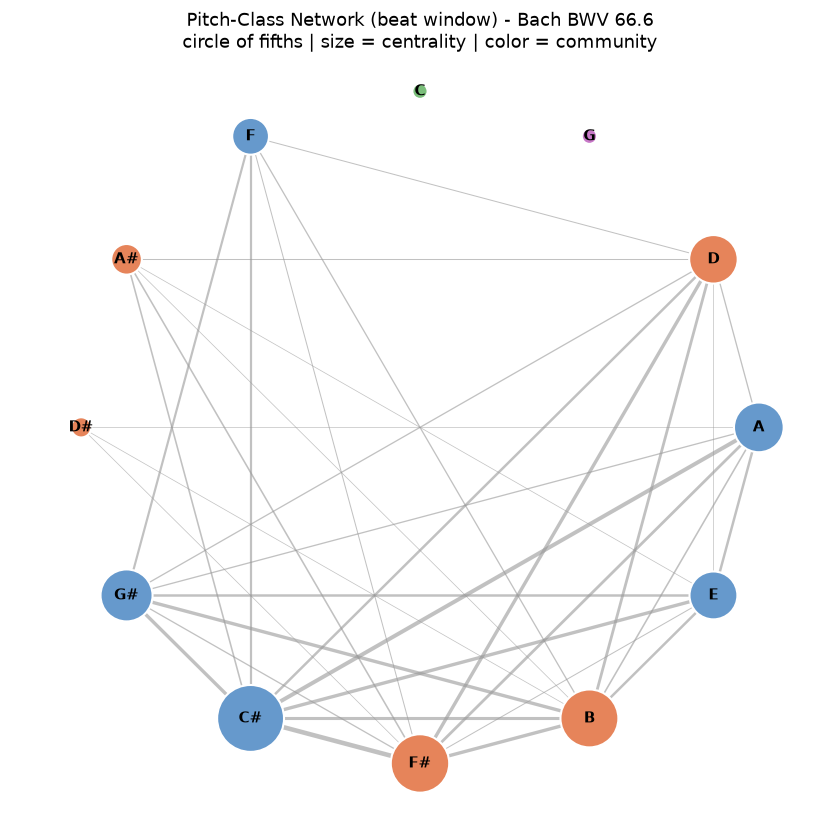

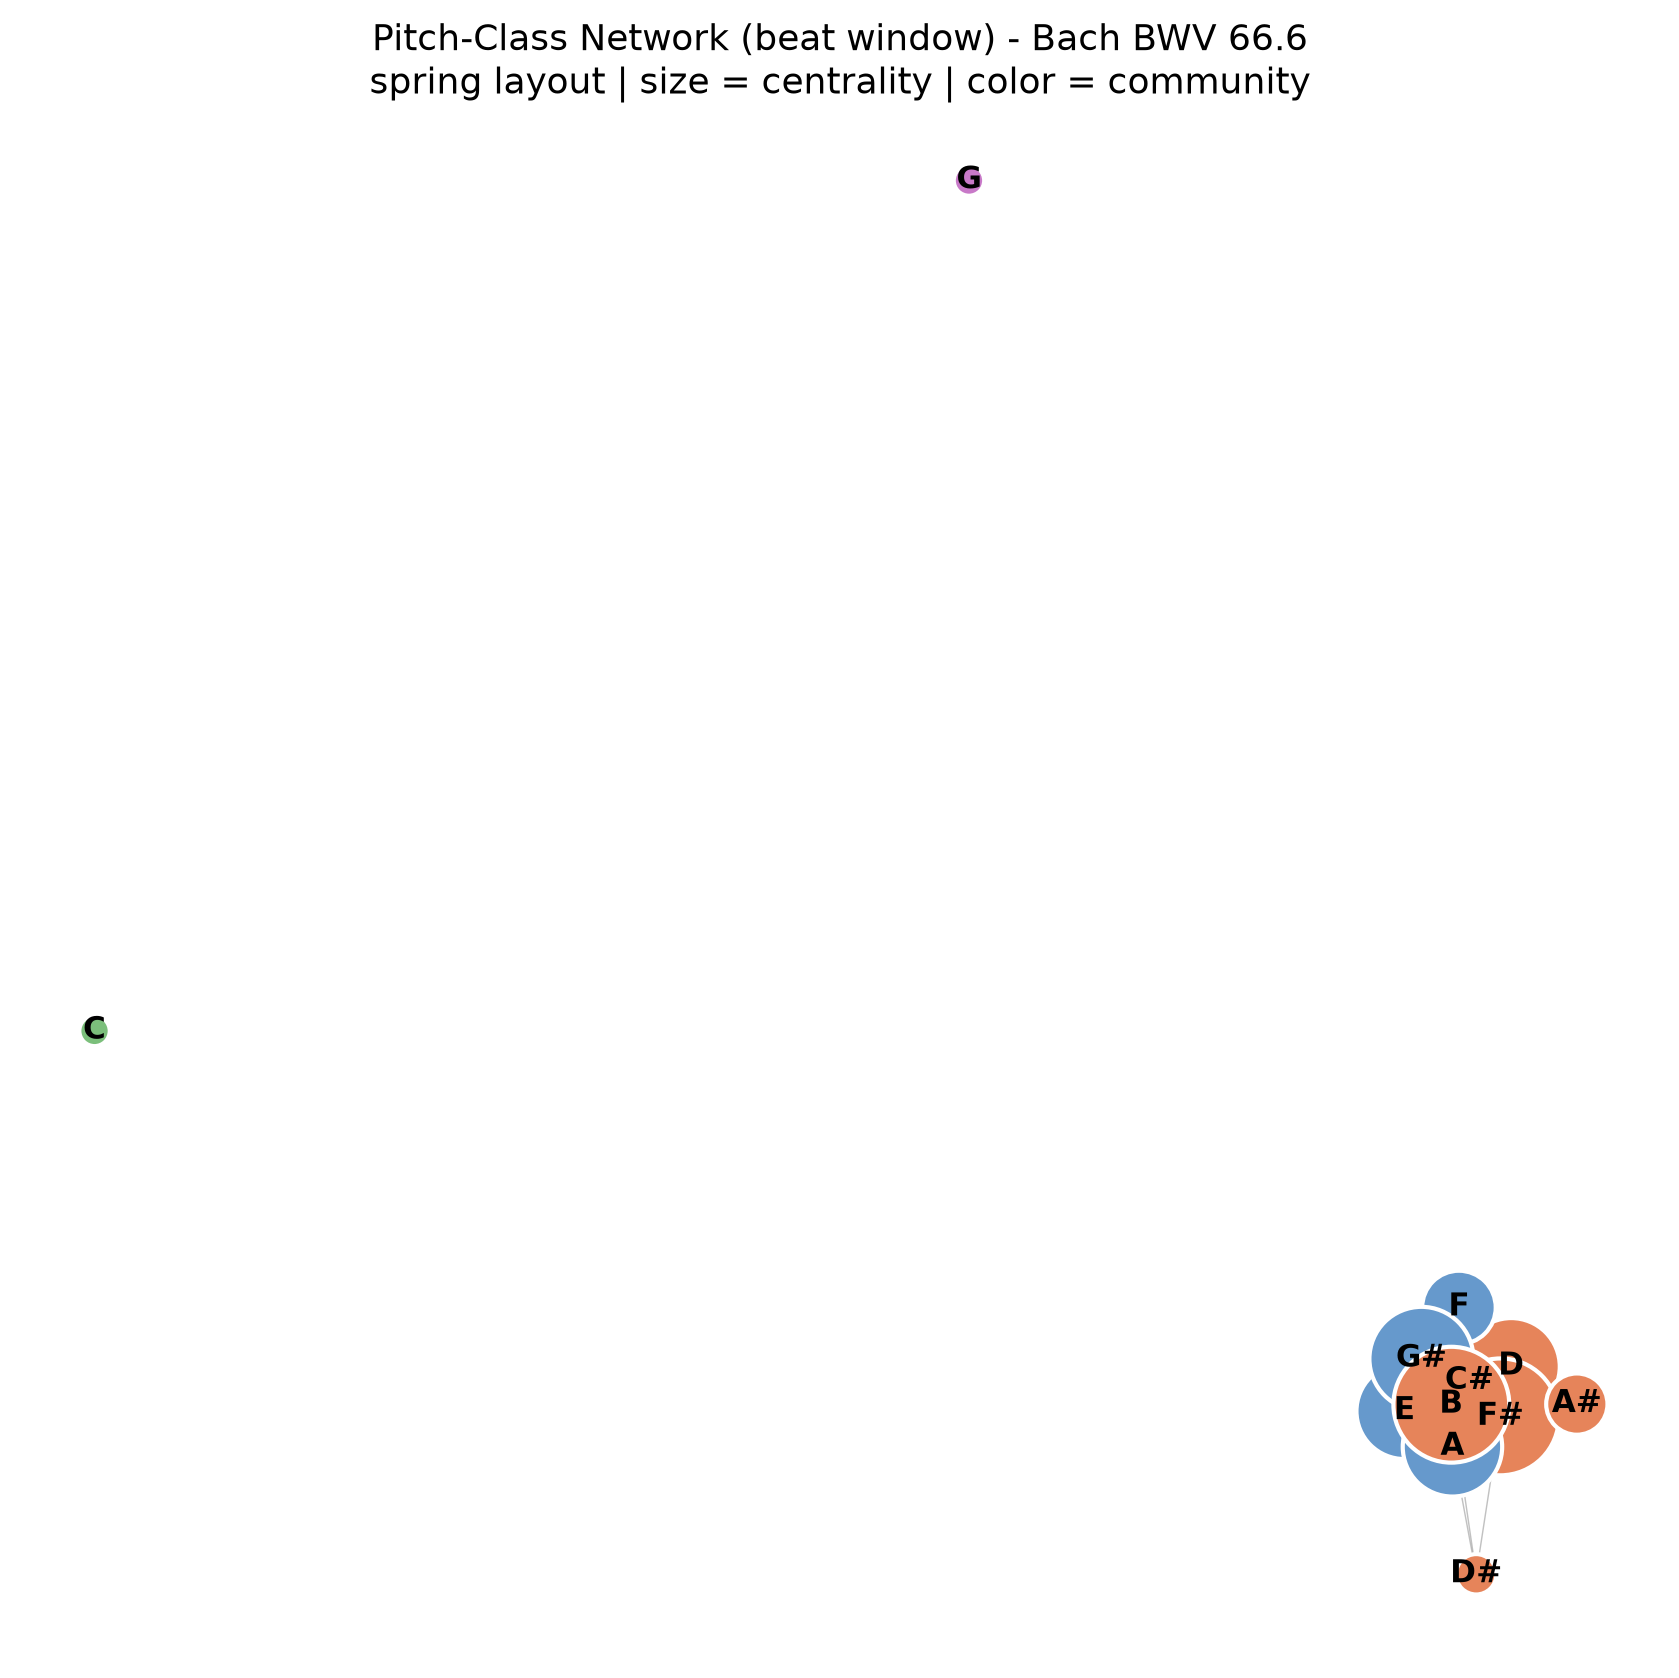

In [10]:
draw_pitch_network(
    G_beat,
    "Pitch-Class Network (beat window) - Bach BWV 66.6\n"
    "circle of fifths | size = centrality | color = community",
    "outputs/pitch_beat_fifths_bwv66_6.png",
    layout="fifths",
)

draw_pitch_network(
    G_beat,
    "Pitch-Class Network (beat window) - Bach BWV 66.6\n"
    "spring layout | size = centrality | color = community",
    "outputs/pitch_beat_spring_bwv66_6.png",
    layout="spring",
)

## Beat window versus measure window

Picking a window is a modeling choice that changes the answer. A wider,
measure-sized window lets more pitch classes share a slice, so the graph comes
out denser. Comparing the two windows is part of the finding.

In [11]:
def pitch_metrics(G):
    """Summary metrics for a pitch graph."""
    deg = dict(G.degree(weight="weight"))
    comms = nx.community.greedy_modularity_communities(G, weight="weight") \
        if G.number_of_edges() else []
    mod = nx.community.modularity(G, comms, weight="weight") if comms else None
    top = max(deg, key=deg.get) if any(deg.values()) else None
    return {
        "active_nodes": sum(1 for n in G.nodes() if deg.get(n, 0) > 0),
        "edges": G.number_of_edges(),
        "density": round(nx.density(G), 3),
        "communities": len(comms),
        "modularity": round(mod, 3) if mod is not None else None,
        "most_central": PC_NAMES[top] if top is not None else None,
    }


measure_windows = pitch_classes_by_window(score, kind="measure")
measure_counts = cooccurrence(measure_windows)
G_measure = pitch_graph(measure_counts)

variant_table = pd.DataFrame([
    {"window": "beat", **pitch_metrics(G_beat)},
    {"window": "measure", **pitch_metrics(G_measure)},
])
variant_table

,window,active_nodes,edges,density,communities,modularity,most_central
0,beat,10,34,0.515,4,0.03,C#
1,measure,10,40,0.606,3,0.00,C#


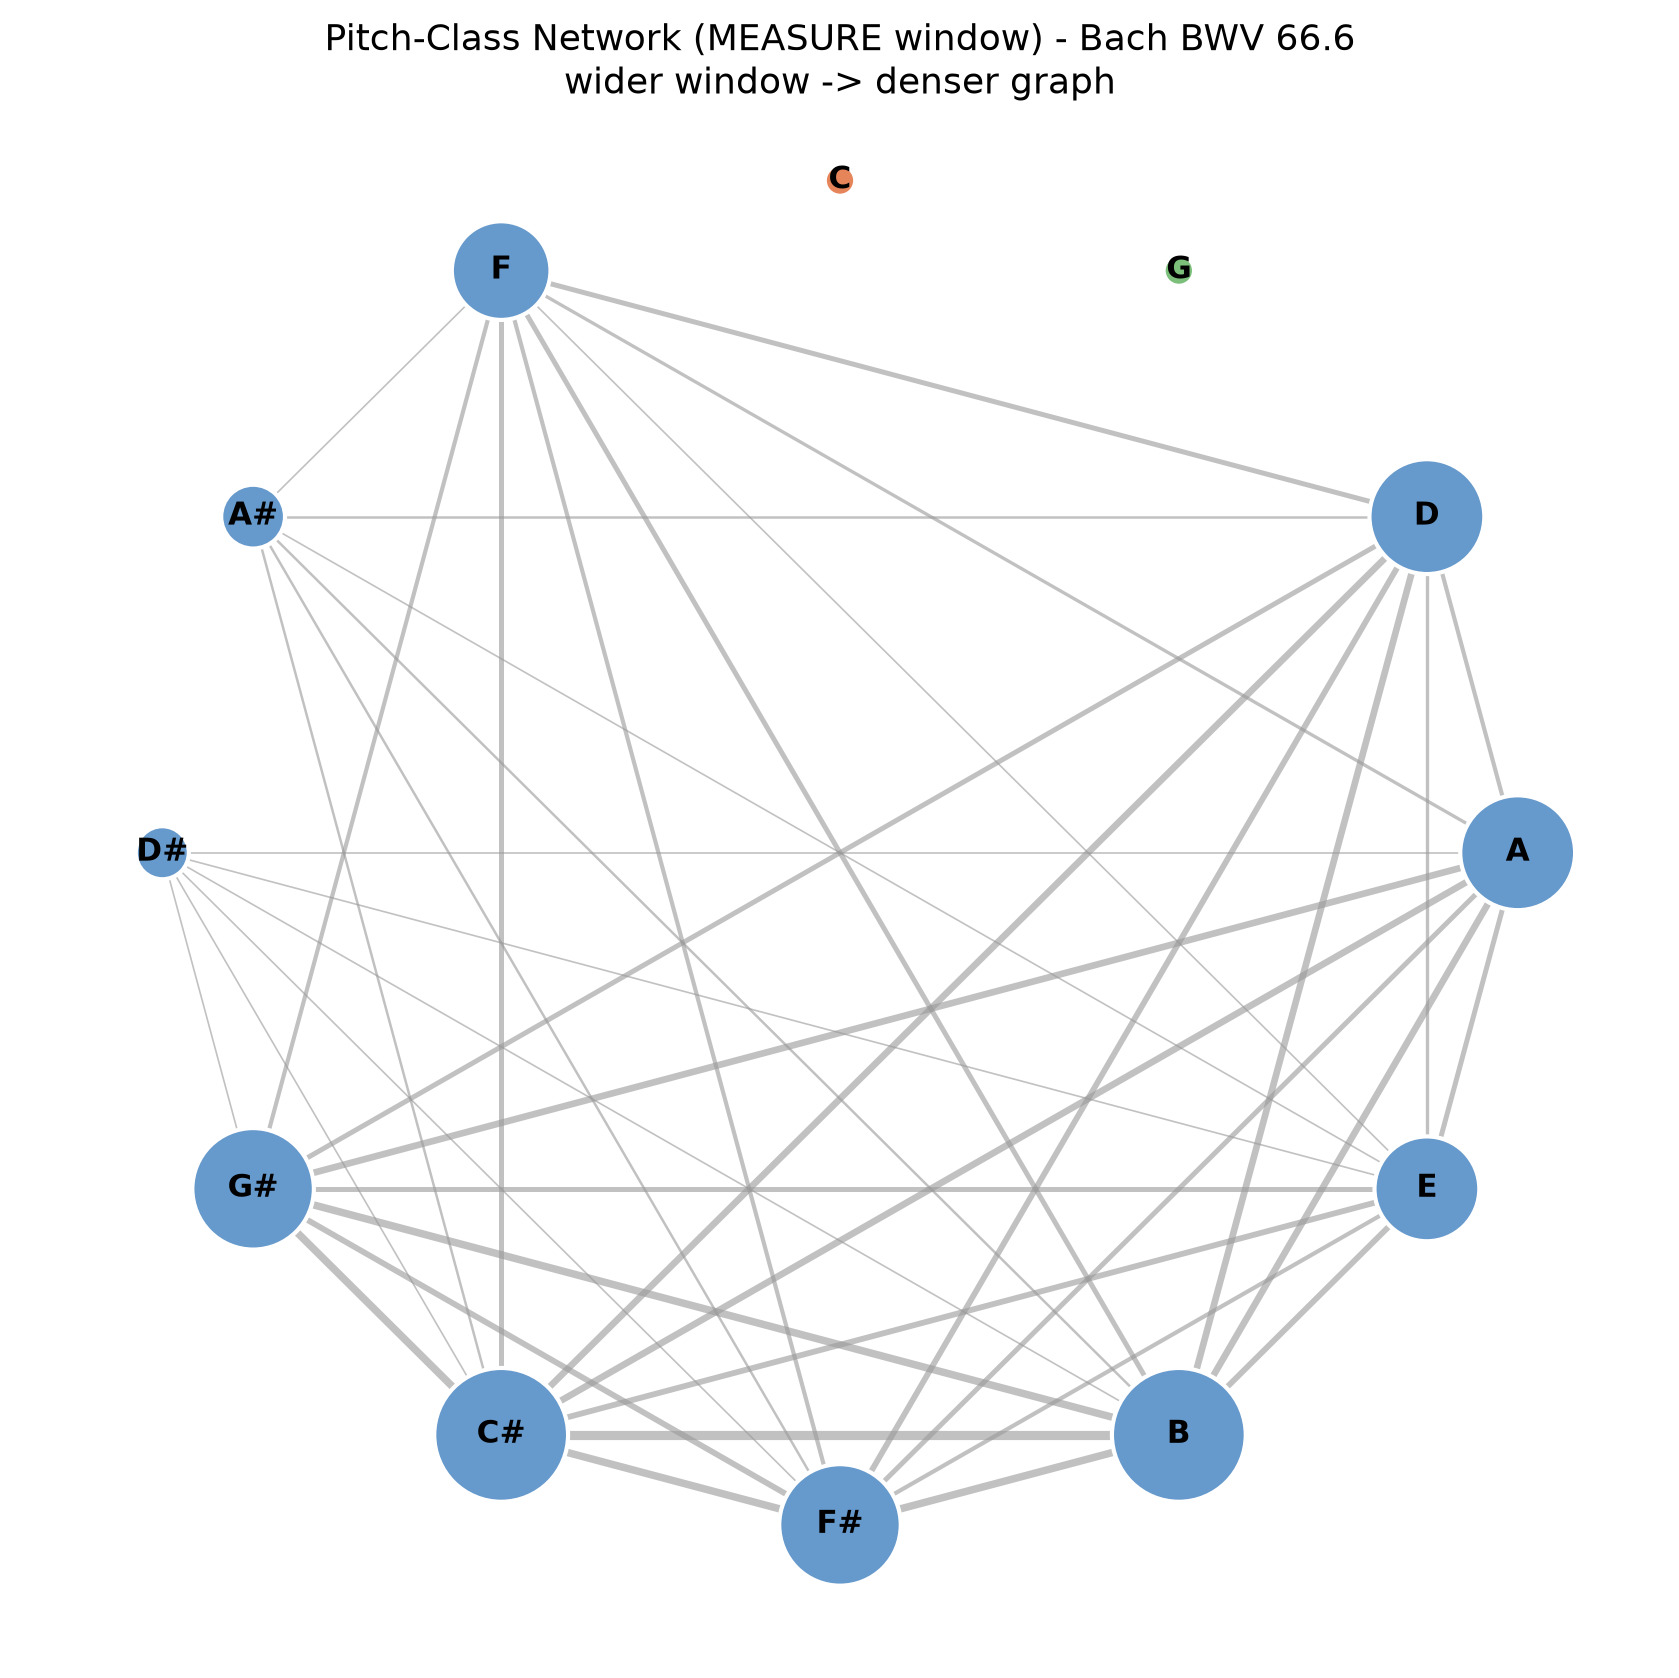

In [12]:
draw_pitch_network(
    G_measure,
    "Pitch-Class Network (MEASURE window) - Bach BWV 66.6\n"
    "wider window -> denser graph",
    "outputs/pitch_measure_fifths_bwv66_6.png",
    layout="fifths",
)

## The instrument network

This asks a different question, and it is the one closest to my orchestra
experience: how is the ensemble put together, and which parts hold the texture?
Here the nodes are the parts, and an edge joins two parts that both sound in the
same measure, weighted by how often that happens.

Instrument network: 4 parts, 6 edges.
   node  weighted_degree
   Alto               30
   Bass               30
Soprano               30
  Tenor               30


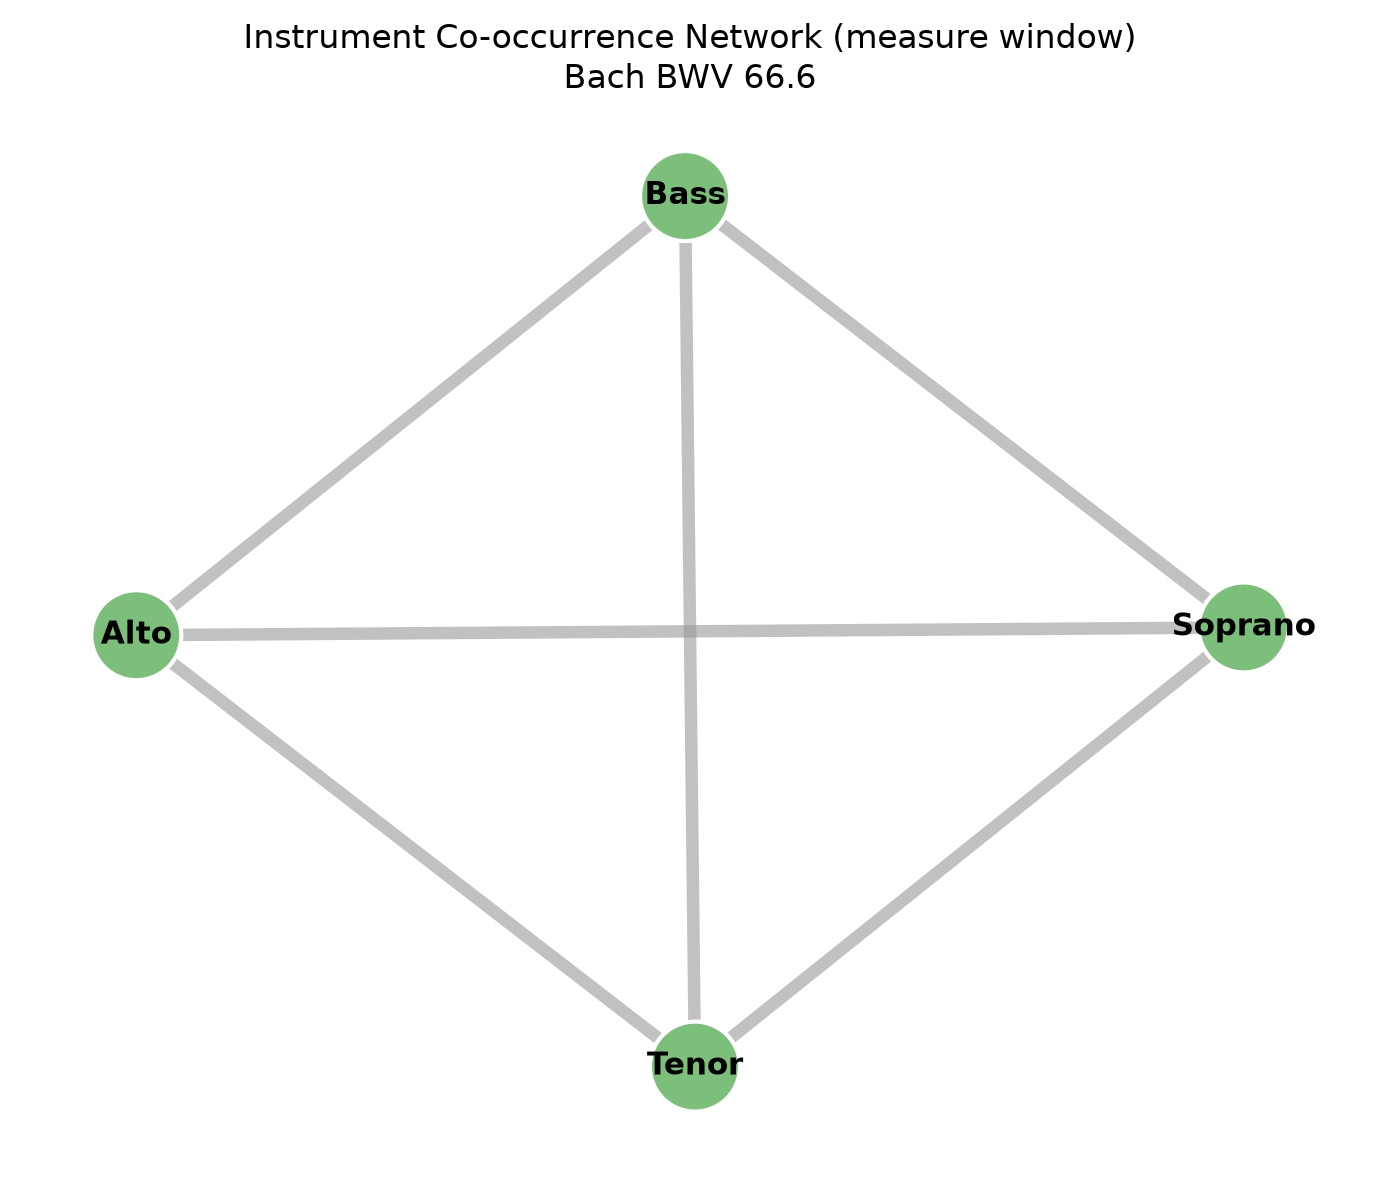

In [13]:
inst_windows = instruments_by_window(score, kind="measure")
inst_counts = cooccurrence(inst_windows)
G_inst = simple_graph(inst_counts)

print(f"Instrument network: {G_inst.number_of_nodes()} parts, "
      f"{G_inst.number_of_edges()} edges.")
print(weighted_degree_table(G_inst).to_string(index=False))

plt.figure(figsize=(7, 6))
pos = nx.spring_layout(G_inst, weight="weight", seed=7)
deg = dict(G_inst.degree(weight="weight"))
sizes = [300 + deg[n] * 25 for n in G_inst.nodes()]
weights = [G_inst[a][b]["weight"] for a, b in G_inst.edges()]
max_w = max(weights)
widths = [0.5 + 4 * (w / max_w) for w in weights]

nx.draw_networkx_edges(G_inst, pos, width=widths, edge_color="#999999", alpha=0.6)
nx.draw_networkx_nodes(G_inst, pos, node_size=sizes, node_color="#7bbf7b",
                       edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(G_inst, pos, font_size=11, font_weight="bold")
plt.title("Instrument Co-occurrence Network (measure window)\nBach BWV 66.6")
plt.axis("off")
plt.tight_layout()
plt.savefig("outputs/instrument_network_bwv66_6.png", dpi=200, bbox_inches="tight")
plt.show()

## Scaling up: many chorales at once

One short piece might be too thin to support a strong claim about its network.
Because the steps are just functions, running them over a big batch of chorales
is easy. I add up the co-occurrence counts from many chorales into a single
aggregate network that shows the harmonic backbone the style shares.

In [14]:
def aggregate_pitch_counts(scores, kind="beat"):
    """Sum pitch-class co-occurrence across many scores; return (counts, table)."""
    total = Counter()
    rows = []
    for sc in scores:
        counts = cooccurrence(pitch_classes_by_window(sc, kind=kind))
        total.update(counts)
        deg = dict(pitch_graph(counts).degree(weight="weight"))
        top = max(deg, key=deg.get) if any(deg.values()) else None
        rows.append({
            "title": (sc.metadata.title or "?")[:32],
            "key": str(sc.analyze("key")),
            "edges": len(counts),
            "most_central": PC_NAMES[top] if top is not None else None,
        })
    return total, pd.DataFrame(rows)


N = 20
chorales = list(corpus.chorales.Iterator(1, N))
agg_counts, piece_table = aggregate_pitch_counts(chorales, kind="beat")
G_agg = pitch_graph(agg_counts)

print(f"Aggregated {len(chorales)} chorales -> {G_agg.number_of_edges()} edges.")
piece_table

Aggregated 20 chorales -> 66 edges.


,title,key,edges,most_central
0,Aus meines Herzens Grunde,G major,24,D
1,"Ich dank’ dir, lieber Herre",A major,36,E
2,"Ach Gott, vom Himmel sieh’ darei",a minor,48,E
3,Es ist das Heil uns kommen her,E major,36,B
4,An Wasserflüssen Babylon,G major,41,D
5,"Christus, der ist mein Leben",F major,27,F
6,"Nun lob’, mein’ Seel’, den Herre",A major,39,A
7,"Freuet euch, ihr Christen alle",f minor,44,F
8,"Ermuntre dich, mein schwacher Ge",G major,42,A
9,Aus tiefer Not schrei’ ich zu di,a minor,32,E


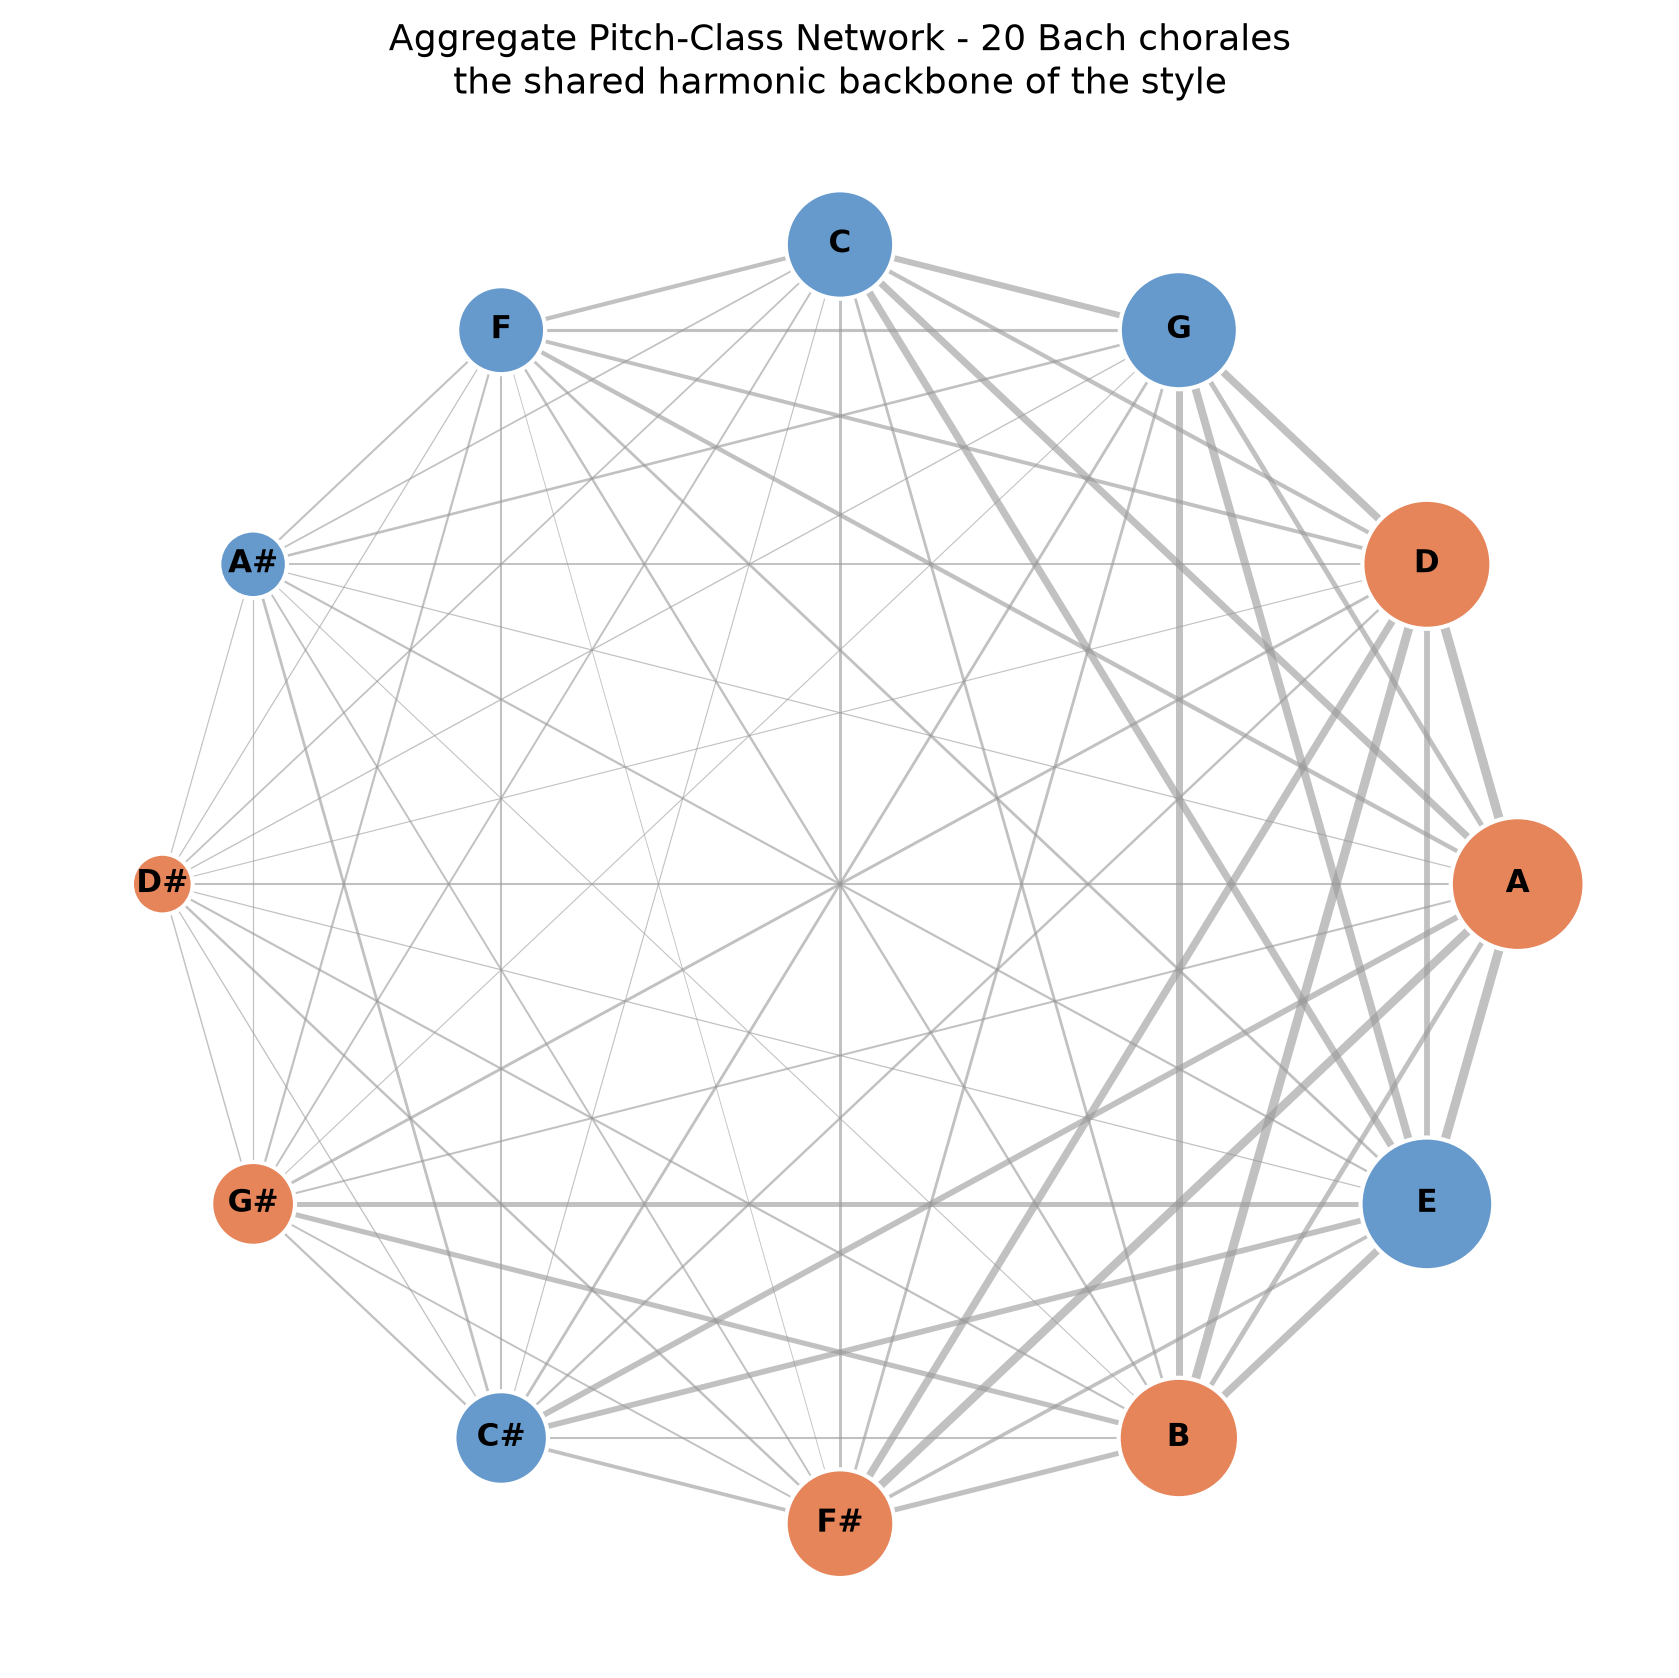

In [15]:
draw_pitch_network(
    G_agg,
    f"Aggregate Pitch-Class Network - {len(chorales)} Bach chorales\n"
    "the shared harmonic backbone of the style",
    "outputs/pitch_aggregate_fifths.png",
    layout="fifths",
)

## Pruning a dense graph

Once a graph has a lot of edges it gets hard to read. Keeping only the heaviest
edges leaves the structure that carries the most weight. Here I keep the top
fraction of edges by weight.

Pruned: 66 -> 27 edges.


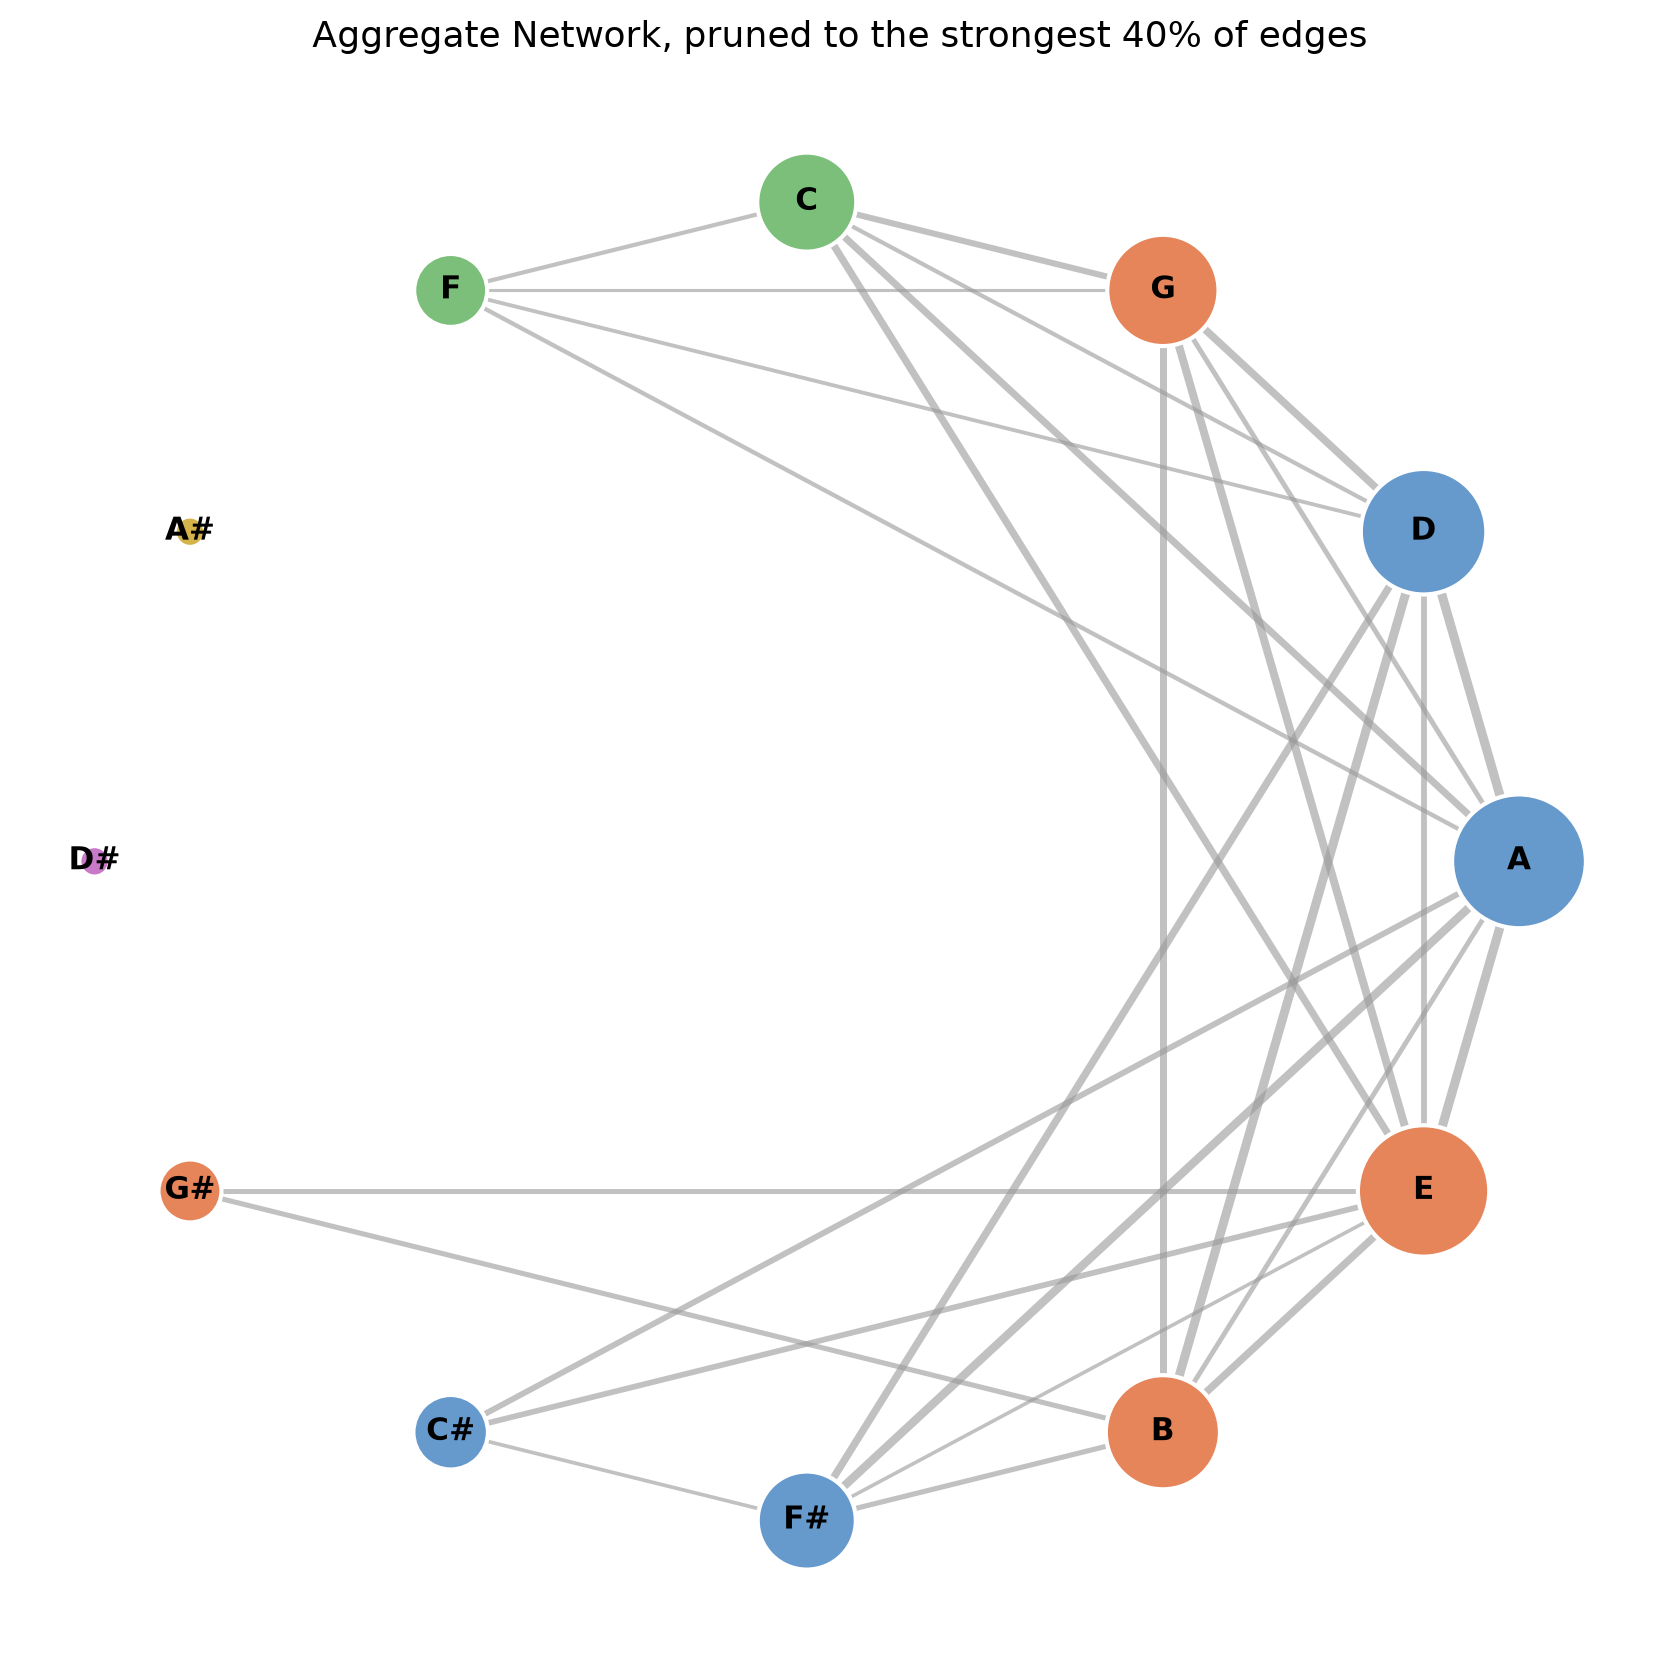

In [16]:
def prune_edges(G, keep_quantile=0.6):
    """Return a copy keeping only edges at/above a weight quantile."""
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    if not weights:
        return G.copy()
    threshold = pd.Series(weights).quantile(keep_quantile)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for a, b, d in G.edges(data=True):
        if d["weight"] >= threshold:
            H.add_edge(a, b, **d)
    return H


G_agg_pruned = prune_edges(G_agg, keep_quantile=0.6)
print(f"Pruned: {G_agg.number_of_edges()} -> {G_agg_pruned.number_of_edges()} edges.")

draw_pitch_network(
    G_agg_pruned,
    "Aggregate Network, pruned to the strongest 40% of edges",
    "outputs/pitch_aggregate_pruned.png",
    layout="fifths",
)

## Findings and limitations

Research question 1 (centrality). For BWV 66.6 the most central pitch classes
come out as the tonic and dominant of the detected key, which is the harmonic
backbone I was hoping to surface. The centrality table and the key print-out
above show the numbers for this run.

Research question 2 (communities). The communities tend to gather the pitch
classes of the key's main triads. The cases I find most interesting are the ones
where a community does not fall neatly onto a single triad, since that usually
points to passing tones, secondary chords, or a modulation.

Research question 3 (across traditions). I did not get to this one. The pipeline
does not care where a score comes from, so `m21.converter.parse("data/file.mid")`
would feed a mariachi or folk MIDI into the same functions. I am leaving the
cross-tradition comparison as future work until I have clean symbolic files for
it.

What the modeling choices cost me:

* The window matters. The beat versus measure table shows that a wider window
  produces a denser graph and shifts which node looks most central, so the window
  is a real interpretive lever.
* Collapsing to twelve pitch classes merges spellings like E# and F. That keeps
  the graph readable and comparable across pieces, at the price of the spelling
  information a theorist might want.
* In a homophonic chorale almost every voice sounds in almost every measure, so
  the instrument network comes out nearly complete. That is honest to the music,
  and it tells me the instrument network will have more to say about textured
  ensemble writing than about chorales.
* Adding up many pieces gives a dense graph that has to be pruned to stay
  readable, and the pruning threshold is one more choice that shapes what you
  see.

## Reflection: what worked, what did not, and what I learned

**What worked.** The central idea held up. Treating a beat as the unit of
co-occurrence and counting pitch-class pairs produced a network whose most central
nodes really are the tonic and dominant of the key. Watching that fall out of the
data, rather than me asserting it, was the point where the project started to feel
like it was telling me something.

**What did not work the first time.**

* My first version labeled nodes with `pitch.name`, which keeps enharmonic
  spellings apart. The graph came out with separate `E#` and `A#` nodes that
  should have folded into the same pitch classes. I switched to
  `pitch.pitchClass` so octaves and spellings collapse into the twelve classes I
  actually wanted.
* My first windowing only looked at where each note started. That quietly dropped
  held notes, so a long note never connected to the faster notes moving
  underneath it. I rewrote the logic to count a note in every beat its full
  duration overlaps, which is much closer to what sounding together really means.
* When I aggregated many chorales, the drawing turned into a clump of giant
  overlapping circles, because I was scaling node size by a fixed number. I
  changed the size to scale relative to the busiest node in each graph so every
  figure stays readable.

**What was hard about the Python.** Most of my time went to learning music21, not
to networkx. A score is a deeply nested object, and figuring out `flatten()`,
offsets, durations, and the measure offset map took a lot of trial and error
because I kept reaching for the wrong attribute. The network side was easier once
the data was in the right shape, although it took some reading to understand what
weighted degree and modularity actually measure before I trusted them.

**What I would do next.** The clear next step is the cross-tradition comparison I
set aside. I want to bring in mariachi or folk MIDI and run it through the same
pipeline, which is the part of my original motivation I did not reach. I would
also try centrality measures beyond degree, such as betweenness, to see whether
they tell a different story about which pitches hold the harmony together.